# Đọc dữ liệu

In [53]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1: IMPORT THƯ VIỆN VÀ LOAD DỮ LIỆU
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Đang tải dữ liệu từ thư mục 'data_output'...")

# 1. Load dữ liệu dành cho mô hình Cây (Tree-based)
df_train_tree = pd.read_csv('data_output/2_data_preprocessed_tree_train.csv')
df_test_tree = pd.read_csv('data_output/2_data_preprocessed_tree_test.csv')

#df_train_tree = pd.read_csv('data_output/3_data_preprocessed_linear_train.csv')
#df_test_tree = pd.read_csv('data_output/3_data_preprocessed_linear_test.csv') 

# Tách X và y (Giả sử cột mục tiêu gốc tên là 'Giá nhà' hoặc 'Khoảng giá')
target_col = 'Khoảng giá' # <-- Sửa lại theo đúng tên cột mục tiêu của bạn
X_train_tree = df_train_tree.drop(columns=[target_col], errors='ignore')
y_train_tree = df_train_tree[target_col] if target_col in df_train_tree.columns else None

X_test_tree = df_test_tree.drop(columns=[target_col], errors='ignore')
y_test_tree = df_test_tree[target_col] if target_col in df_test_tree.columns else None

# 2. Load dữ liệu dành cho mô hình Tuyến tính (Linear-based)
df_train_linear = pd.read_csv('data_output/3_data_preprocessed_linear_train.csv')
df_test_linear = pd.read_csv('data_output/3_data_preprocessed_linear_test.csv')

X_train_linear = df_train_linear.drop(columns=[target_col], errors='ignore')
# Lưu ý: y_train_linear lúc này đã được Log1p từ bước trước
y_train_linear = df_train_linear[target_col] if target_col in df_train_linear.columns else None

X_test_linear = df_test_linear.drop(columns=[target_col], errors='ignore')
y_test_linear = df_test_linear[target_col] if target_col in df_test_linear.columns else None

print("✅ Đã tải dữ liệu thành công! Sẵn sàng cho phân tích và huấn luyện.")

⏳ Đang tải dữ liệu từ thư mục 'data_output'...
✅ Đã tải dữ liệu thành công! Sẵn sàng cho phân tích và huấn luyện.


In [54]:
print(X_train_tree.columns)
print(X_train_linear.columns)

Index(['Diện tích', 'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude',
       'Longitude', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo', 'hem_xe_hoi',
       'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc', 'duong_vao_null_flag', 'Duong',
       'Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Dat_O',
       'Tổng số phòng', 'khoang_cach_trung_tam'],
      dtype='object')
Index(['Diện tích', 'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude',
       'Longitude', 'Quan_Huyen', 'Phuong_Xa', 'Dien_Tich_Lo', 'hem_xe_hoi',
       'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc', 'duong_vao_null_flag', 'Duong',
       'Ty_Le_Giao_Thong', 'Ty_Le_Cong_Cong_CX', 'Ty_Le_Dat_O',
       'Tổng số phòng', 'khoang_cach_trung_tam'],
      dtype='object')


# Thử nghiệm trên mô hình

## 1. MÔ HÌNH CÂY TRÊN BỘ DỮ LIỆU CÂY

🧪 Thí nghiệm: Huấn luyện mô hình Cây (Input đã Log1p - Đánh giá trên giá gốc)...

✅ Random Forest      -> Huấn luyện thành công!
❌ Gradient Boosting  -> Thất bại! (Lỗi: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values)
✅ XGBoost            -> Huấn luyện thành công!
✅ LightGBM           -> Huấn luyện thành công!


,Mô hình,R2 Score,MAE,MSE,MAPE,RMSLE,Status
0,Random Forest,0.6368,5.84,424.67,0.3359,0.3509,Success
1,Gradient Boosting,0.0000,0.00,0.00,0.0000,0.0000,Failed (ValueError)
2,XGBoost,0.6906,5.48,361.76,0.4010,0.3158,Success
3,LightGBM,0.7063,5.32,343.42,0.4003,0.3112,Success


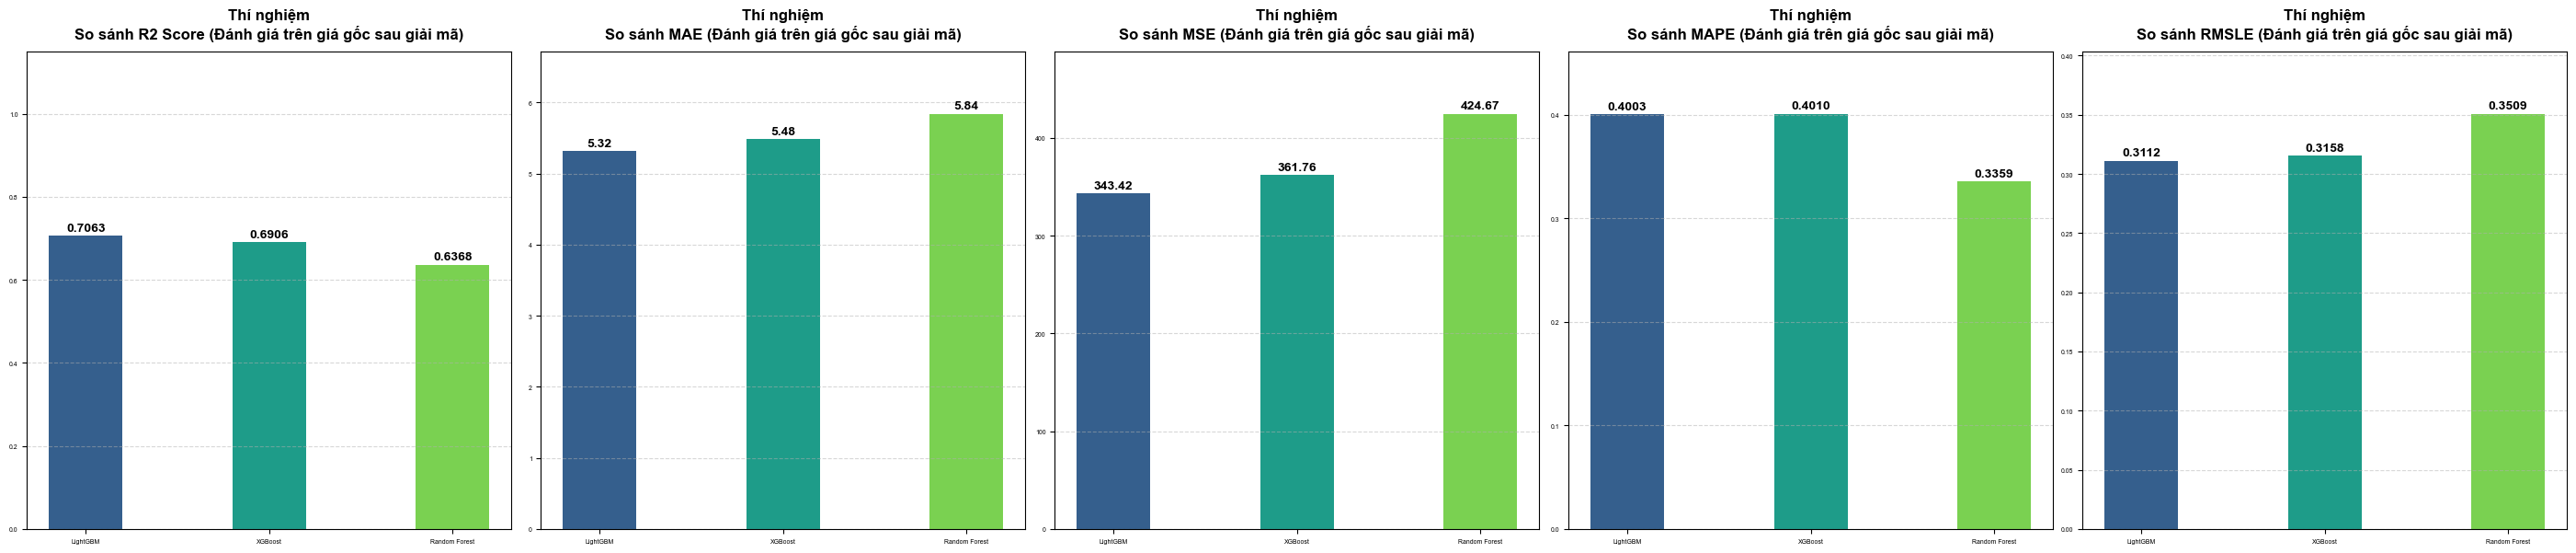

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, mean_squared_log_error

# =========================================================================
# ⚙️ CẤU HÌNH THÍ NGHIỆM
# =========================================================================
# Set True: Nếu y_train/y_test đã được log1p (Sẽ giải mã ngược expm1 khi đánh giá)
# Set False: Nếu y_train/y_test đang ở giá trị gốc (Đánh giá trực tiếp)
IS_TARGET_LOGGED = True  
# =========================================================================

# Xác định tiêu đề in ra dựa trên tham số
if IS_TARGET_LOGGED:
    print("🧪 Thí nghiệm: Huấn luyện mô hình Cây (Input đã Log1p - Đánh giá trên giá gốc)...\n")
else:
    print("🧪 Thí nghiệm: Huấn luyện mô hình Cây (Input Gốc - KHÔNG LOG)...\n")

tree_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

results = []

for name, model in tree_models.items():
    try:
        # KIỂM TRA ĐỘ TƯƠNG THÍCH KÍCH THƯỚC DỮ LIỆU
        if len(X_train_tree) != len(y_train_tree):
            raise ValueError(f"Lệch kích thước! X_train có {len(X_train_tree)} dòng, y_train có {len(y_train_tree)} dòng.")
            
        # 1. Huấn luyện mô hình
        model.fit(X_train_tree, y_train_tree)
        
        # 2. Dự báo
        preds_raw = model.predict(X_test_tree)
        
        # 3. LUỒNG XỬ LÝ THEO THAM SỐ IS_TARGET_LOGGED
        if IS_TARGET_LOGGED:
            # Nếu đầu vào đã log -> Giải mã ngược về gốc
            preds_eval = np.expm1(preds_raw)
            y_test_eval = np.expm1(y_test_tree)
        else:
            # Nếu đầu vào là gốc -> Giữ nguyên để đánh giá
            preds_eval = preds_raw
            y_test_eval = y_test_tree
        
        # 4. Tính toán toàn bộ các metrics trên dữ liệu dùng để đánh giá (y_test_eval)
        r2 = r2_score(y_test_eval, preds_eval)
        mae = mean_absolute_error(y_test_eval, preds_eval)
        mse = mean_squared_error(y_test_eval, preds_eval)
        mape = mean_absolute_percentage_error(y_test_eval, preds_eval)
        
        # Tính RMSLE: clip(0, None) để tránh lỗi hàm Log với các dự đoán âm
        preds_clipped = np.clip(preds_eval, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_test_eval, preds_clipped))
        
        results.append({
            "Mô hình": name, 
            "R2 Score": round(r2, 4), 
            "MAE": round(mae, 2), 
            "MSE": round(mse, 2), 
            "MAPE": round(mape, 4),      
            "RMSLE": round(rmsle, 4),    
            "Status": "Success"
        })
        print(f"✅ {name:<18} -> Huấn luyện thành công!")
        
    except Exception as e:
        results.append({
            "Mô hình": name, "R2 Score": 0, "MAE": 0, "MSE": 0, 
            "MAPE": 0, "RMSLE": 0, "Status": f"Failed ({type(e).__name__})"
        })
        print(f"❌ {name:<18} -> Thất bại! (Lỗi: {e})")

# -------------------------------------------------------------------------
# HIỂN THỊ VÀ VẼ BIỂU ĐỒ SO SÁNH
# -------------------------------------------------------------------------
df_res = pd.DataFrame(results)
display(df_res)

success_res = df_res[df_res["Status"] == "Success"].sort_values(by="R2 Score", ascending=False)

if not success_res.empty:
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    
    metrics = ['R2 Score', 'MAE', 'MSE', 'MAPE', 'RMSLE']
    colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(success_res)))
    
    # Đặt lại tên tiêu đề biểu đồ theo tham số
    chart_suffix = "(Đánh giá trên giá gốc sau giải mã)" if IS_TARGET_LOGGED else "(Gốc - Không Log)"

    for i, metric in enumerate(metrics):
        ax = axes[i] 
        bars = ax.bar(success_res['Mô hình'], success_res[metric], color=colors, width=0.4)
        ax.set_title(f'Thí nghiệm\nSo sánh {metric} {chart_suffix}', fontsize=12, fontweight='bold', pad=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Chỉnh trục Y
        if metric == 'R2 Score': 
            ax.set_ylim(0, 1.15)
        else: 
            ax.set_ylim(0, success_res[metric].max() * 1.15)
            
        # Thêm text giá trị lên đầu mỗi cột
        for bar in bars:
            h = bar.get_height()
            text_format = f"{h:,.4f}" if metric in ['R2 Score', 'MAPE', 'RMSLE'] else f"{h:,.2f}"
            ax.text(bar.get_x() + bar.get_width()/2., h + (ax.get_ylim()[1]*0.01), 
                    text_format, ha='center', fontweight='bold', fontsize=10)
            
    plt.tight_layout()
    plt.show()

## 4. MÔ HÌNH HỒI QUY TRÊN BỘ DỮ LIỆU LINEAR

In [56]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: KIỂM TRA TOÀN DIỆN SỰ TỒN TẠI CỦA NaN TRONG CÁC TẬP TUYẾN TÍNH
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd

def check_nan_summary(df, name):
    if df is None:
        print(f"❌ Biến {name} chưa được khởi tạo!")
        return
    nan_count = df.isna().sum().sum()
    if nan_count > 0:
        print(f"⚠️ {name:<25}: Vẫn còn {nan_count:>4} ô trống (NaN).")
        # In ra top các cột bị dính NaN để dễ debug
        nan_per_col = df.isna().sum()
        cols_with_nan = nan_per_col[nan_per_col > 0]
        print(f"   👉 Chi tiết các cột bị trống: {cols_with_nan.to_dict()}")
    else:
        print(f"✅ {name:<25}: Hoàn toàn SẠCH SẼ (0 NaN).")

print("📊 --- KIỂM TRA CÁC TẬP DỮ LIỆU GỐC (ORIGINAL) ---")
check_nan_summary(X_train_linear, "X_train_linear (Gốc)")
check_nan_summary(X_test_linear, "X_test_linear (Gốc)")

print("\n✨ --- KIỂM TRA CÁC TẬP ĐÃ LÀM SẠCH (CLEANED) ---")
# Kiểm tra các biến được tạo ra từ SimpleImputer trong Cell 5.4
try:
    check_nan_summary(X_train_linear_clean, "X_train_linear_clean")
    check_nan_summary(X_test_linear_clean, "X_test_linear_clean")
except NameError:
    print("❌ Không tìm thấy các tập '_clean'. Hãy chắc chắn bạn đã chạy Cell 5.4 trước!")

print("\n🎯 --- KIỂM TRA BIẾN MỤC TIÊU (TARGET) ---")
# Ép sang Series để dùng hàm isna() nếu đang là numpy array
y_train_series = pd.Series(y_train_linear) if isinstance(y_train_linear, (list, np.ndarray)) else y_train_linear
y_test_series = pd.Series(y_test_tree) if isinstance(y_test_tree, (list, np.ndarray)) else y_test_tree

print(f"{'y_train_linear':<25}: {y_train_series.isna().sum()} NaN")
print(f"{'y_test_tree':<25}: {y_test_series.isna().sum()} NaN")

📊 --- KIỂM TRA CÁC TẬP DỮ LIỆU GỐC (ORIGINAL) ---
⚠️ X_train_linear (Gốc)     : Vẫn còn 3862 ô trống (NaN).
   👉 Chi tiết các cột bị trống: {'Dien_Tich_Lo': 961, 'Ty_Le_Giao_Thong': 967, 'Ty_Le_Cong_Cong_CX': 967, 'Ty_Le_Dat_O': 967}
⚠️ X_test_linear (Gốc)      : Vẫn còn  913 ô trống (NaN).
   👉 Chi tiết các cột bị trống: {'Dien_Tich_Lo': 226, 'Ty_Le_Giao_Thong': 229, 'Ty_Le_Cong_Cong_CX': 229, 'Ty_Le_Dat_O': 229}

✨ --- KIỂM TRA CÁC TẬP ĐÃ LÀM SẠCH (CLEANED) ---
✅ X_train_linear_clean     : Hoàn toàn SẠCH SẼ (0 NaN).
✅ X_test_linear_clean      : Hoàn toàn SẠCH SẼ (0 NaN).

🎯 --- KIỂM TRA BIẾN MỤC TIÊU (TARGET) ---
y_train_linear           : 0 NaN
y_test_tree              : 0 NaN


In [57]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: XỬ LÝ DỮ LIỆU THIẾU (IMPUTATION) BẰNG MEDIAN
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
from sklearn.impute import SimpleImputer

print("⏳ Bắt đầu quá trình điền khuyết (Median)...")

# 1. Khởi tạo công cụ điền khuyết với chiến lược 'median'
imputer = SimpleImputer(strategy='median')

# 2. Fit (Học giá trị median từ tập Train) & Transform (Điền vào tập Train)
# Lưu ý: SimpleImputer trả về numpy array, nên cần ép lại thành DataFrame và giữ nguyên tên cột/index
X_train_linear_clean = pd.DataFrame(
    imputer.fit_transform(X_train_linear), 
    columns=X_train_linear.columns,
    index=X_train_linear.index
)

# 3. Transform (Dùng median đã học ở Train để điền vào tập Test)
X_test_linear_clean = pd.DataFrame(
    imputer.transform(X_test_linear), 
    columns=X_test_linear.columns,
    index=X_test_linear.index
)

# 4. Kiểm tra lại kết quả
nan_train_after = X_train_linear_clean.isna().sum().sum()
nan_test_after = X_test_linear_clean.isna().sum().sum()

print("✅ Đã xử lý điền khuyết bằng Median thành công!")
print(f"   👉 Số lượng NaN còn lại trong X_train_linear_clean: {nan_train_after}")
print(f"   👉 Số lượng NaN còn lại trong X_test_linear_clean: {nan_test_after}")

X_test_linear = X_test_linear_clean
X_train_linear = X_train_linear_clean

⏳ Bắt đầu quá trình điền khuyết (Median)...
✅ Đã xử lý điền khuyết bằng Median thành công!
   👉 Số lượng NaN còn lại trong X_train_linear_clean: 0
   👉 Số lượng NaN còn lại trong X_test_linear_clean: 0


🧪 Chạy Thí nghiệm 4: Toàn bộ nhóm Hồi quy trên Dữ liệu Linear (Train LOG - Đánh giá THỰC)...

✨ Dữ liệu không có NaN.
🚀 Linear Regression  -> Huấn luyện thành công!
🚀 Ridge Regression   -> Huấn luyện thành công!
🚀 Lasso Regression   -> Huấn luyện thành công!
🚀 ElasticNet         -> Huấn luyện thành công!


,Mô hình,R2 Score,MAE,MSE,MAPE,RMSLE,Status
0,Linear Regression,0.5604,7.16,514.08,0.3189,0.432,Success
1,Ridge Regression,0.5603,7.16,514.16,0.3189,0.432,Success
2,Lasso Regression,0.5593,7.16,515.37,0.3187,0.432,Success
3,ElasticNet,0.5597,7.16,514.91,0.3188,0.432,Success


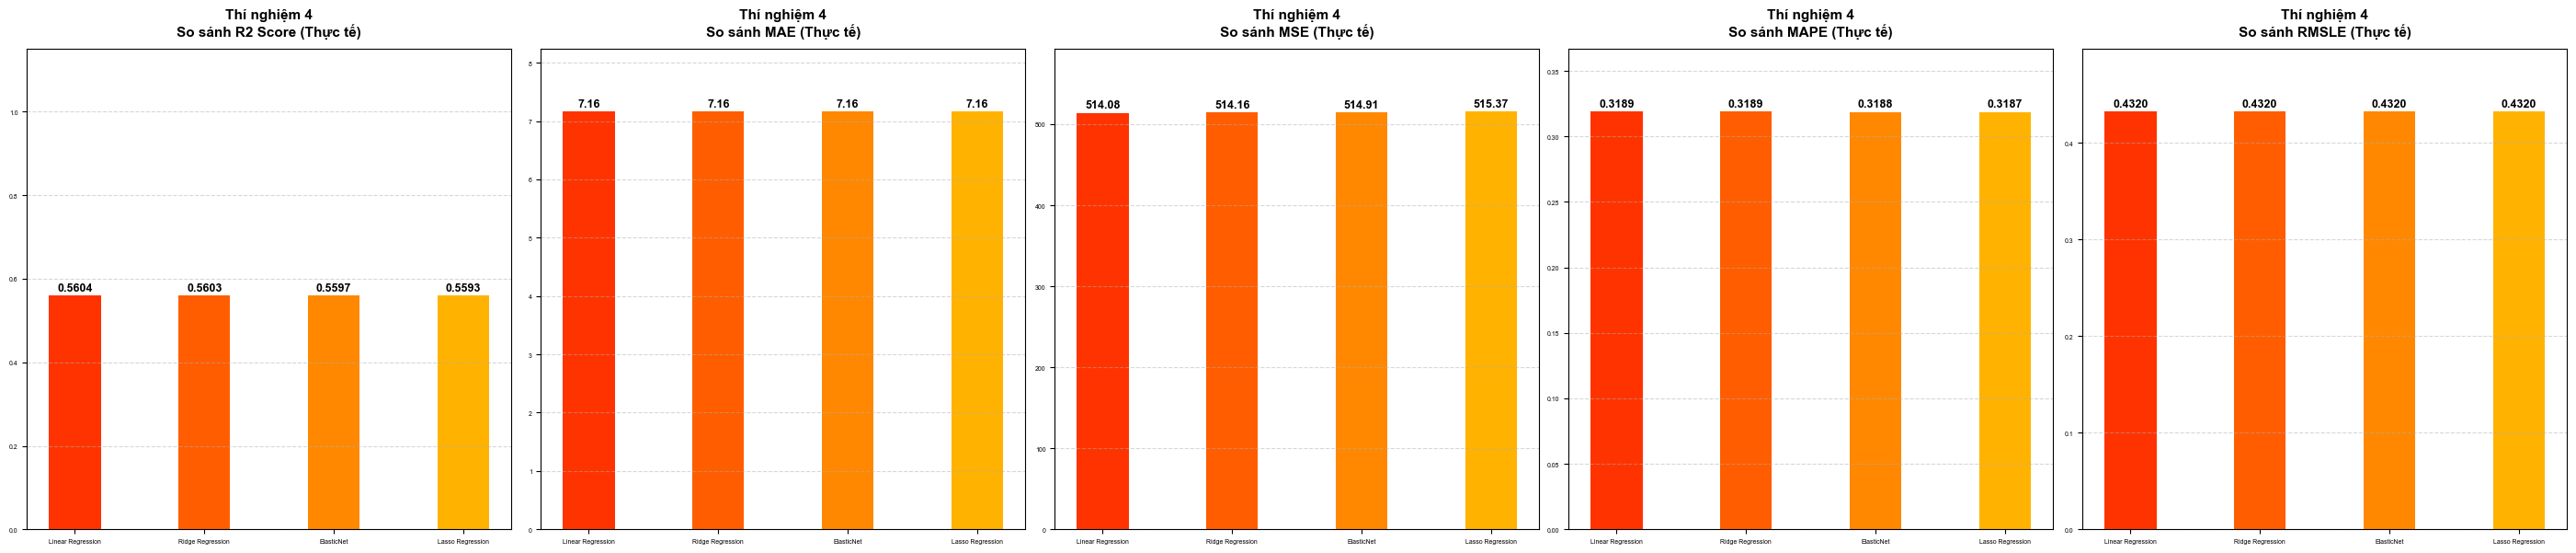

In [58]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5.4: THÍ NGHIỆM 4 - NHÓM HỒI QUY (ĐÃ FIX LỖI R2 VÀ THÊM SCALING)
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, mean_squared_log_error

print("🧪 Chạy Thí nghiệm 4: Toàn bộ nhóm Hồi quy trên Dữ liệu Linear (Train LOG - Đánh giá THỰC)...\n")

# -------------------------------------------------------------------------
# 1. TIỀN XỬ LÝ: ĐIỀN KHUYẾT & CHUẨN HÓA SCALING (BẮT BUỘC CHO LINEAR)
# -------------------------------------------------------------------------
nan_in_train = X_train_linear.isna().sum().sum()
nan_in_test = X_test_linear.isna().sum().sum()

if nan_in_train > 0 or nan_in_test > 0:
    print(f"⚠️ Phát hiện NaN. Đang điền Median...")
    imputer = SimpleImputer(strategy='median')
    X_train_clean = imputer.fit_transform(X_train_linear)
    X_test_clean = imputer.transform(X_test_linear)
else:
    print("✨ Dữ liệu không có NaN.")
    X_train_clean = X_train_linear.values
    X_test_clean = X_test_linear.values

# ĐÃ THÊM: Chuẩn hóa dữ liệu (StandardScaler) cho mô hình tuyến tính
scaler = StandardScaler()
X_train_linear_scaled = scaler.fit_transform(X_train_clean)
X_test_linear_scaled = scaler.transform(X_test_clean)

# -------------------------------------------------------------------------
# 2. HUẤN LUYỆN VÀ ĐÁNH GIÁ
# -------------------------------------------------------------------------
linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000), 
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
}

results_4 = []

for name, model in linear_models.items():
    try:
        # Huấn luyện trên tập ĐÃ SCALED
        model.fit(X_train_linear_scaled, y_train_linear)
        preds_log = model.predict(X_test_linear_scaled)
        
        # ĐÃ SỬA LỖI BUG: Giải mã cả Dự đoán LẪN Thực tế
        preds_real = np.expm1(preds_log)
        y_test_real = np.expm1(y_test_tree)  # <--- DÒNG QUAN TRỌNG ĐÃ THÊM
        
        # Tính toán trên tập y_test_real (KHÔNG DÙNG y_test_tree log nữa)
        r2 = r2_score(y_test_real, preds_real)
        mae = mean_absolute_error(y_test_real, preds_real)
        mse = mean_squared_error(y_test_real, preds_real)
        mape = mean_absolute_percentage_error(y_test_real, preds_real)
        
        preds_real_clipped = np.clip(preds_real, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_test_real, preds_real_clipped))
        
        results_4.append({
            "Mô hình": name, "R2 Score": round(r2, 4), "MAE": round(mae, 2), 
            "MSE": round(mse, 2), "MAPE": round(mape, 4), "RMSLE": round(rmsle, 4), 
            "Status": "Success"
        })
        print(f"🚀 {name:<18} -> Huấn luyện thành công!")
    except Exception as e:
        results_4.append({
            "Mô hình": name, "R2 Score": 0, "MAE": 0, "MSE": 0, 
            "MAPE": 0, "RMSLE": 0, "Status": f"Failed ({type(e).__name__})"
        })
        print(f"❌ {name:<18} -> Thất bại! (Lỗi: {e})")

# -------------------------------------------------------------------------
# 3. HIỂN THỊ KẾT QUẢ VÀ VẼ BIỂU ĐỒ
# -------------------------------------------------------------------------
df_res4 = pd.DataFrame(results_4)
display(df_res4)

success_res4 = df_res4[df_res4["Status"] == "Success"].sort_values(by="R2 Score", ascending=False)

if not success_res4.empty:
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    metrics = ['R2 Score', 'MAE', 'MSE', 'MAPE', 'RMSLE']
    colors = plt.cm.autumn(np.linspace(0.2, 0.7, len(success_res4)))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        bars = ax.bar(success_res4['Mô hình'], success_res4[metric], color=colors, width=0.4)
        ax.set_title(f'Thí nghiệm 4\nSo sánh {metric} (Thực tế)', fontsize=11, fontweight='bold', pad=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        if metric == 'R2 Score': 
            ax.set_ylim(0, 1.15)
        else: 
            ax.set_ylim(0, success_res4[metric].max() * 1.15)
            
        for bar in bars:
            h = bar.get_height()
            text_format = f"{h:,.4f}" if metric in ['R2 Score', 'MAPE', 'RMSLE'] else f"{h:,.2f}"
            ax.text(bar.get_x() + bar.get_width()/2., h + (ax.get_ylim()[1]*0.01), 
                    text_format, ha='center', fontweight='bold', fontsize=9)
            
    plt.tight_layout()
    plt.show()

In [60]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5.4: THÍ NGHIỆM 4 & TỔNG HỢP BIỂU ĐỒ 2 NHÓM MÔ HÌNH (IEEE 2x5)
# ───────────────────────────────────────────────────────────────────────
# CƠ CHẾ: Điền khuyết -> Train LOG -> Đánh giá THỰC -> Vẽ gộp Exp 1 & 4
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, mean_squared_log_error

print("🧪 Chạy Thí nghiệm 4: Toàn bộ nhóm Hồi quy trên Dữ liệu Linear (Train LOG - Đánh giá THỰC)...\n")

# -------------------------------------------------------------------------
# 1. TIỀN XỬ LÝ & ĐIỀN KHUYẾT
# -------------------------------------------------------------------------
nan_in_train = X_train_linear.isna().sum().sum()
nan_in_test = X_test_linear.isna().sum().sum()

if nan_in_train > 0 or nan_in_test > 0:
    print(f"⚠️ Phát hiện {nan_in_train} NaN (Train) và {nan_in_test} NaN (Test). Đang điền Median...")
    imputer = SimpleImputer(strategy='median')
    X_train_linear_clean = pd.DataFrame(imputer.fit_transform(X_train_linear), columns=X_train_linear.columns)
    X_test_linear_clean = pd.DataFrame(imputer.transform(X_test_linear), columns=X_test_linear.columns)
    print("✅ Đã xử lý làm sạch dữ liệu xong!\n")
else:
    print("✨ Dữ liệu đầu vào hoàn toàn sạch sẽ, không có NaN.\n")
    X_train_linear_clean = X_train_linear.copy()
    X_test_linear_clean = X_test_linear.copy()

# -------------------------------------------------------------------------
# 2. HUẤN LUYỆN & ĐÁNH GIÁ (THÍ NGHIỆM 4)
# -------------------------------------------------------------------------
linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000), 
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
}

results_4 = []

for name, model in linear_models.items():
    try:
        if len(X_train_linear_clean) != len(y_train_linear):
            raise ValueError(f"Lệch kích thước! X_train: {len(X_train_linear_clean)}, y_train: {len(y_train_linear)}")
            
        model.fit(X_train_linear_clean, y_train_linear)
        preds_log = model.predict(X_test_linear_clean)
        
        # Chuyển đổi ngược về giá thực tế
        preds_real = np.expm1(preds_log)
        
        r2 = r2_score(y_test_tree, preds_real)
        mae = mean_absolute_error(y_test_tree, preds_real)
        mse = mean_squared_error(y_test_tree, preds_real)
        mape = mean_absolute_percentage_error(y_test_tree, preds_real)
        
        preds_real_clipped = np.clip(preds_real, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_test_tree, preds_real_clipped))
        
        results_4.append({
            "Mô hình": name, "R2 Score": round(r2, 4), "MAE": round(mae, 2), 
            "MSE": round(mse, 2), "MAPE": round(mape, 4), "RMSLE": round(rmsle, 4), 
            "Status": "Success"
        })
        print(f"🚀 {name:<18} -> Huấn luyện thành công!")
    except Exception as e:
        results_4.append({
            "Mô hình": name, "R2 Score": 0, "MAE": 0, "MSE": 0, 
            "MAPE": 0, "RMSLE": 0, "Status": f"Failed ({type(e).__name__})"
        })
        print(f"❌ {name:<18} -> Thất bại! (Lỗi: {e})")

df_res4 = pd.DataFrame(results_4)
display(df_res4)

# =========================================================================
# 3. VẼ BIỂU ĐỒ TỔNG HỢP (THÍ NGHIỆM 1 & 4) - CHUẨN IEEE 2x5
# =========================================================================
# Giả định biến df_res1 (từ Thí nghiệm 1) đã tồn tại trong bộ nhớ
try:
    success_res1 = df_res1[df_res1["Status"] == "Success"].copy()
except NameError:
    print("⚠️ Cảnh báo: Không tìm thấy df_res1. Vui lòng chạy lại cell Thí nghiệm 1 trước.")
    success_res1 = pd.DataFrame()

success_res4 = df_res4[df_res4["Status"] == "Success"].copy()

if not success_res1.empty and not success_res4.empty:
    
    # Typography IEEE - Đảm bảo toàn bộ font đều là normal (không in đậm)
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 6, 'axes.titlesize': 7, 'axes.labelsize': 6,
        'xtick.labelsize': 5, 'ytick.labelsize': 5,
        'font.weight': 'normal', 'axes.titleweight': 'normal'
    })

    # Rút gọn tên mô hình
    map_tree = {"Random Forest": "RF", "Gradient Boosting": "GBDT", "XGBoost": "XGB", "LightGBM": "LGBM"}
    map_linear = {"Linear Regression": "LR", "Ridge Regression": "Ridge", "Lasso Regression": "Lasso", "ElasticNet": "ENet"}
    
    success_res1['Mô hình ngắn'] = success_res1['Mô hình'].map(map_tree)
    success_res4['Mô hình ngắn'] = success_res4['Mô hình'].map(map_linear)

    # Khởi tạo Grid 2x5, bề rộng chuẩn chính xác 2 cột (7.16 inches)
    fig, axes = plt.subplots(2, 5, figsize=(7.16, 4.0), dpi=300)
    
    metrics = ['R2 Score', 'MAE', 'MSE', 'MAPE', 'RMSLE']
    
    colors_tree = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    colors_linear = ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    letters = [['(a)', '(b)', '(c)', '(d)', '(e)'], 
               ['(f)', '(g)', '(h)', '(i)', '(j)']]

    for row, (df_plot, colors, group_name) in enumerate(zip(
        [success_res1, success_res4], 
        [colors_tree, colors_linear], 
        ['Tree Models', 'Linear Models']
    )):
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            bars = ax.bar(df_plot['Mô hình ngắn'], df_plot[metric], color=colors[:len(df_plot)], width=0.5)
            
            # Tiêu đề in thường hoàn toàn (fontweight='normal')
            short_metric = metric.lower()
            ax.set_title(f"{letters[row][col]} {short_metric} ({'tree' if row==0 else 'linear'})", 
                         loc='left', pad=4, fontweight='normal')
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(axis='y', linestyle='--', linewidth=0.2, alpha=0.7)
            
            if metric == 'R2 Score': 
                ax.set_ylim(0, 1.25)
            else: 
                ax.set_ylim(0, df_plot[metric].max() * 1.35)
                
            # Gắn text trên bar (không in đậm: fontweight='normal')
            for bar in bars:
                h = bar.get_height()
                text_format = f"{h:.4f}" if metric in ['R2 Score', 'MAPE', 'RMSLE'] else f"{h:.2f}"
                ax.text(bar.get_x() + bar.get_width()/2., h + (ax.get_ylim()[1]*0.02), 
                        text_format, ha='center', va='bottom', fontsize=4.5, fontweight='normal')

    plt.tight_layout(w_pad=1.0, h_pad=1.5)
    plt.savefig('combined_experiments_ieee_normal.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()

🧪 Chạy Thí nghiệm 4: Toàn bộ nhóm Hồi quy trên Dữ liệu Linear (Train LOG - Đánh giá THỰC)...

✨ Dữ liệu đầu vào hoàn toàn sạch sẽ, không có NaN.

🚀 Linear Regression  -> Huấn luyện thành công!
🚀 Ridge Regression   -> Huấn luyện thành công!
🚀 Lasso Regression   -> Huấn luyện thành công!
🚀 ElasticNet         -> Huấn luyện thành công!


,Mô hình,R2 Score,MAE,MSE,MAPE,RMSLE,Status
0,Linear Regression,-840.1299,13.60,530.98,4.5610,1.4153,Success
1,Ridge Regression,-836.7227,13.59,528.83,4.5601,1.4153,Success
2,Lasso Regression,-822.8036,13.56,520.04,4.5557,1.4147,Success
3,ElasticNet,-823.5109,13.57,520.49,4.5555,1.4147,Success


/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_18473/457887993.py:149: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(w_pad=1.0, h_pad=1.5)


🧪 Chạy Thí nghiệm 4: Toàn bộ nhóm Hồi quy (Train LOG - Đánh giá THỰC)...

✨ Dữ liệu đầu vào sạch sẽ, không có NaN.

🚀 Linear Regression  -> Huấn luyện thành công!
🚀 Ridge Regression   -> Huấn luyện thành công!
🚀 Lasso Regression   -> Huấn luyện thành công!
🚀 ElasticNet         -> Huấn luyện thành công!


,Mô hình,R2 Score,MAE,MSE,MAPE,RMSLE,Status
0,Linear Regression,0.5604,7.16,514.08,0.3189,0.432,Success
1,Ridge Regression,0.5603,7.16,514.16,0.3189,0.432,Success
2,Lasso Regression,0.5593,7.16,515.37,0.3187,0.432,Success
3,ElasticNet,0.5597,7.16,514.91,0.3188,0.432,Success


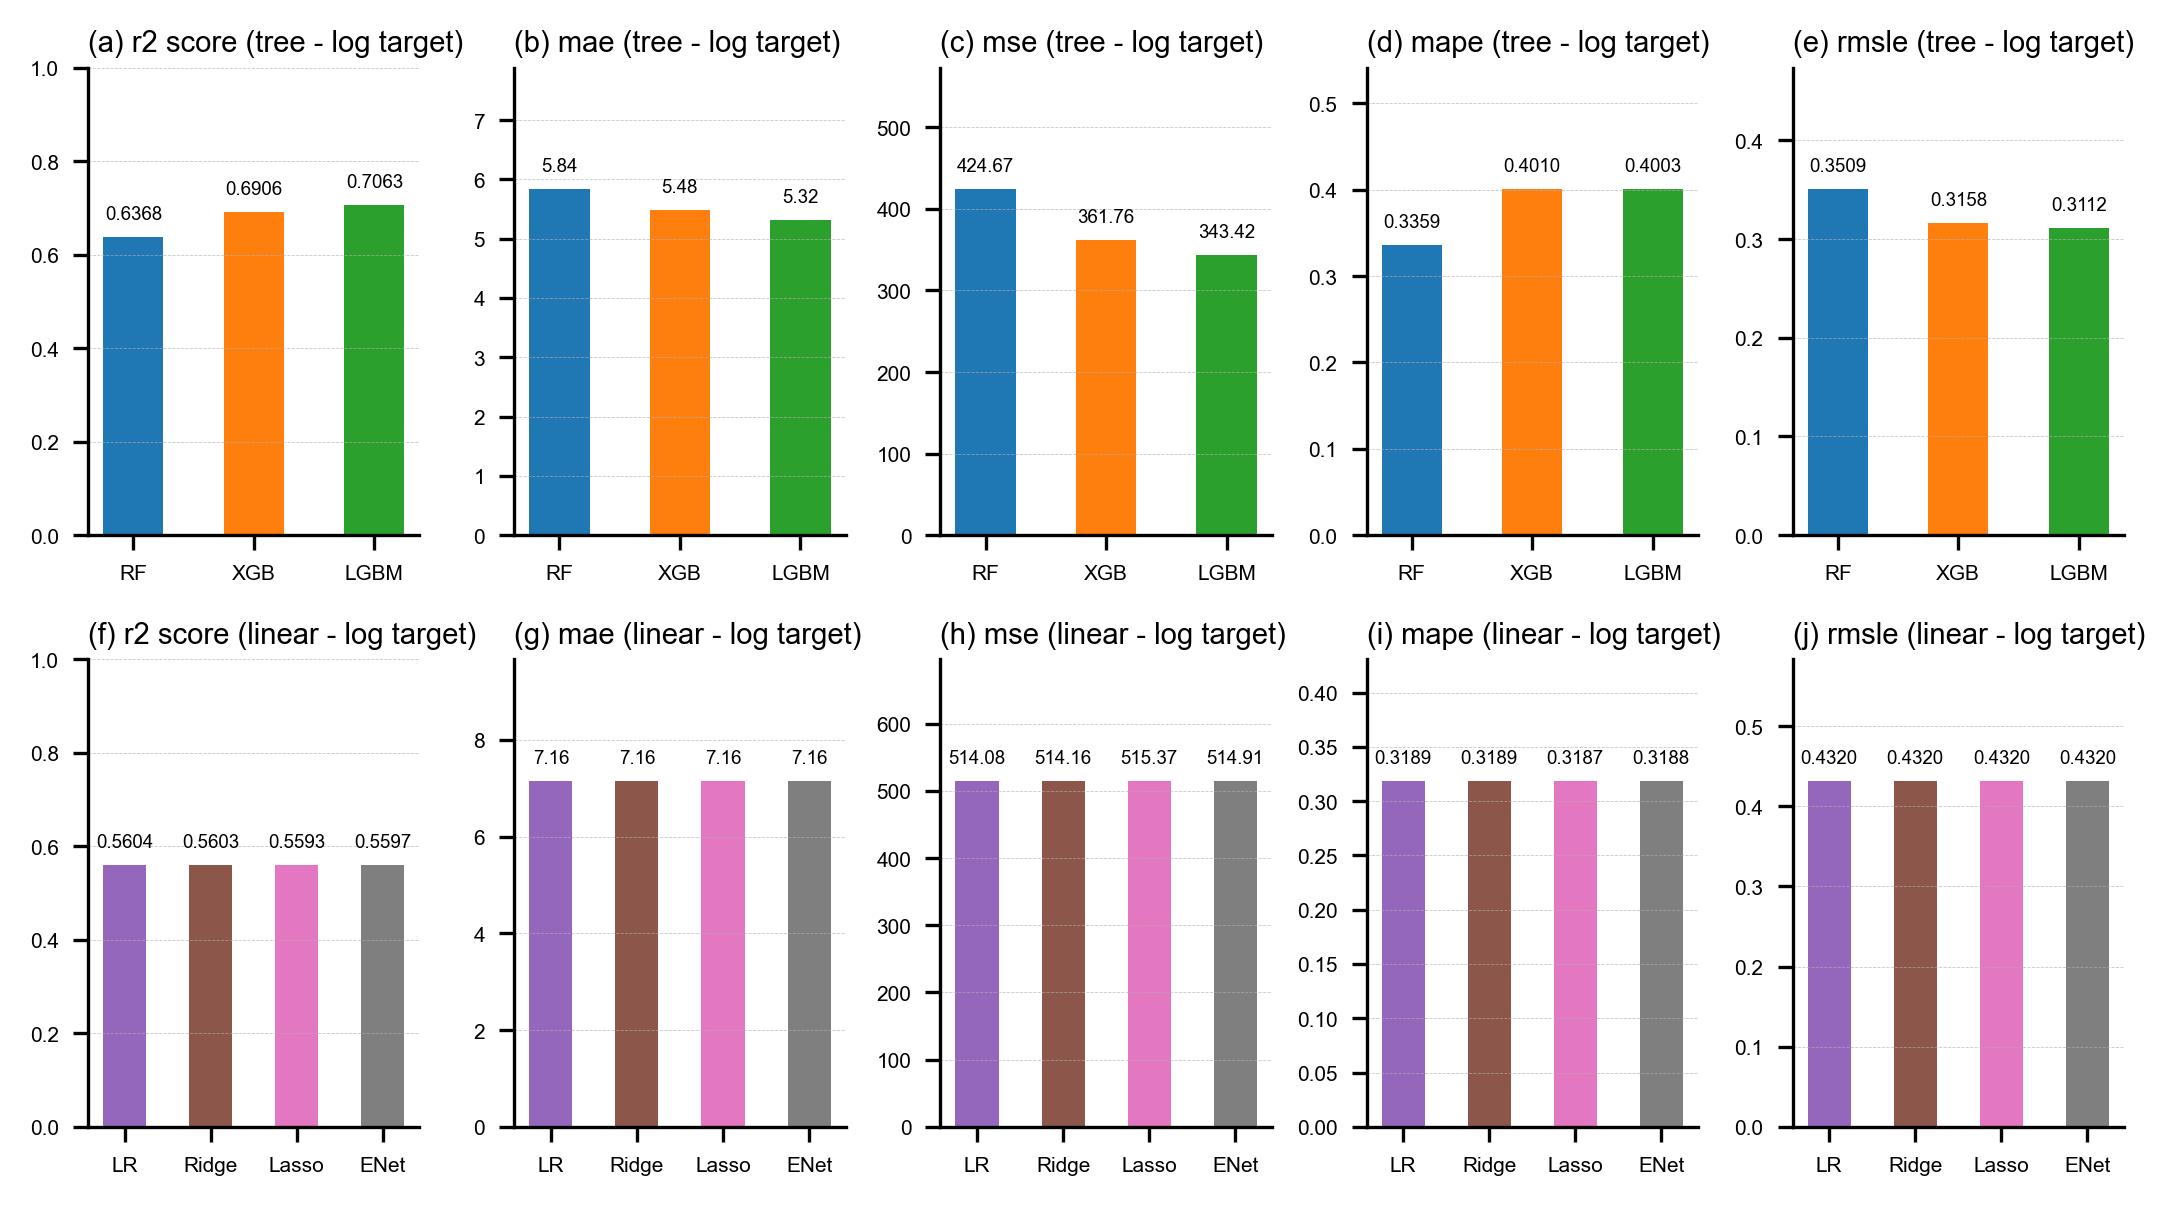

In [61]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5.4: THÍ NGHIỆM 4 & TỔNG HỢP BIỂU ĐỒ 2 NHÓM MÔ HÌNH (IEEE 2x5)
# ───────────────────────────────────────────────────────────────────────
# CƠ CHẾ: Điền khuyết -> Chuẩn hóa -> Train LOG -> Đánh giá THỰC -> Vẽ gộp
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, mean_squared_log_error

print("🧪 Chạy Thí nghiệm 4: Toàn bộ nhóm Hồi quy (Train LOG - Đánh giá THỰC)...\n")

# -------------------------------------------------------------------------
# 1. TIỀN XỬ LÝ: ĐIỀN KHUYẾT & CHUẨN HÓA
# -------------------------------------------------------------------------
nan_in_train = X_train_linear.isna().sum().sum()
nan_in_test = X_test_linear.isna().sum().sum()

if nan_in_train > 0 or nan_in_test > 0:
    print(f"⚠️ Phát hiện {nan_in_train} NaN (Train) và {nan_in_test} NaN (Test). Đang điền Median...")
    imputer = SimpleImputer(strategy='median')
    X_train_clean = imputer.fit_transform(X_train_linear)
    X_test_clean = imputer.transform(X_test_linear)
    print("✅ Đã xử lý điền khuyết!\n")
else:
    print("✨ Dữ liệu đầu vào sạch sẽ, không có NaN.\n")
    X_train_clean = X_train_linear.values
    X_test_clean = X_test_linear.values

# BẮT BUỘC: Chuẩn hóa dữ liệu cho mô hình Tuyến tính để tránh R2 bị âm
scaler = StandardScaler()
X_train_linear_scaled = scaler.fit_transform(X_train_clean)
X_test_linear_scaled = scaler.transform(X_test_clean)

# -------------------------------------------------------------------------
# 2. HUẤN LUYỆN & ĐÁNH GIÁ
# -------------------------------------------------------------------------
linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000), 
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
}

results_4 = []

for name, model in linear_models.items():
    try:
        # Train trên dữ liệu đã SCALED
        model.fit(X_train_linear_scaled, y_train_linear)
        preds_log = model.predict(X_test_linear_scaled)
        
        # SỬA LỖI BUG: Chuyển đổi CẢ DỰ ĐOÁN và THỰC TẾ về giá gốc
        preds_real = np.expm1(preds_log)
        y_test_real = np.expm1(y_test_tree) # Giải mã y_test_tree đang bị Log
        
        # Tính toán metric chuẩn xác trên không gian giá gốc
        r2 = r2_score(y_test_real, preds_real)
        mae = mean_absolute_error(y_test_real, preds_real)
        mse = mean_squared_error(y_test_real, preds_real)
        mape = mean_absolute_percentage_error(y_test_real, preds_real)
        
        preds_real_clipped = np.clip(preds_real, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_test_real, preds_real_clipped))
        
        results_4.append({
            "Mô hình": name, "R2 Score": round(r2, 4), "MAE": round(mae, 2), 
            "MSE": round(mse, 2), "MAPE": round(mape, 4), "RMSLE": round(rmsle, 4), 
            "Status": "Success"
        })
        print(f"🚀 {name:<18} -> Huấn luyện thành công!")
    except Exception as e:
        results_4.append({
            "Mô hình": name, "R2 Score": 0, "MAE": 0, "MSE": 0, 
            "MAPE": 0, "RMSLE": 0, "Status": f"Failed ({type(e).__name__})"
        })
        print(f"❌ {name:<18} -> Thất bại! (Lỗi: {e})")

df_res4 = pd.DataFrame(results_4)
display(df_res4)

# =========================================================================
# 3. VẼ BIỂU ĐỒ TỔNG HỢP (THÍ NGHIỆM TREE & LINEAR) - CHUẨN IEEE 2x5
# =========================================================================
try:
    success_res_tree = df_res[df_res["Status"] == "Success"].copy()
    tree_label = "tree - log target" if IS_TARGET_LOGGED else "tree - raw target"
except NameError:
    print("⚠️ Cảnh báo: Không tìm thấy biến df_res. Bạn chưa chạy cell mô hình Cây trước đó.")
    success_res_tree = pd.DataFrame()
    tree_label = "tree"

success_res4 = df_res4[df_res4["Status"] == "Success"].copy()

if not success_res_tree.empty and not success_res4.empty:
    
    # Typography chuẩn IEEE
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 6, 'axes.titlesize': 7, 'axes.labelsize': 6,
        'xtick.labelsize': 5, 'ytick.labelsize': 5,
        'font.weight': 'normal', 'axes.titleweight': 'normal'
    })

    # Đổi tên mô hình cho ngắn gọn để vừa khung hình
    map_tree = {"Random Forest": "RF", "Gradient Boosting": "GBDT", "XGBoost": "XGB", "LightGBM": "LGBM"}
    map_linear = {"Linear Regression": "LR", "Ridge Regression": "Ridge", "Lasso Regression": "Lasso", "ElasticNet": "ENet"}
    
    success_res_tree['Mô hình ngắn'] = success_res_tree['Mô hình'].map(map_tree).fillna(success_res_tree['Mô hình'])
    success_res4['Mô hình ngắn'] = success_res4['Mô hình'].map(map_linear).fillna(success_res4['Mô hình'])

    # Khởi tạo Grid 2x5 (7.16 inches = chuẩn chiều rộng 2 cột bài báo)
    fig, axes = plt.subplots(2, 5, figsize=(7.16, 4.0), dpi=300)
    
    metrics = ['R2 Score', 'MAE', 'MSE', 'MAPE', 'RMSLE']
    colors_tree = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    colors_linear = ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    letters = [['(a)', '(b)', '(c)', '(d)', '(e)'], 
               ['(f)', '(g)', '(h)', '(i)', '(j)']]

    for row, (df_plot, colors, group_name) in enumerate(zip(
        [success_res_tree, success_res4], 
        [colors_tree, colors_linear], 
        [tree_label, 'linear - log target']
    )):
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            bars = ax.bar(df_plot['Mô hình ngắn'], df_plot[metric], color=colors[:len(df_plot)], width=0.5)
            
            short_metric = metric.lower()
            ax.set_title(f"{letters[row][col]} {short_metric} ({group_name})", 
                         loc='left', pad=4, fontweight='normal')
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(axis='y', linestyle='--', linewidth=0.2, alpha=0.7)
            
            # Cân chỉnh trục Y linh hoạt, chống lỗi hiển thị nếu R2 vẫn còn âm nhẹ
            max_val = df_plot[metric].max()
            if metric == 'R2 Score': 
                min_val = min(0, df_plot[metric].min() * 1.1)
                ax.set_ylim(min_val, max(1.0, max_val * 1.25))
            else: 
                ax.set_ylim(0, max_val * 1.35)
                
            # Gắn text lên thanh Bar
            for bar in bars:
                h = bar.get_height()
                text_format = f"{h:.4f}" if metric in ['R2 Score', 'MAPE', 'RMSLE'] else f"{h:.2f}"
                # Định vị trí text để không bị đè vạch
                y_pos = h + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03
                if h < 0: y_pos = h - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.08
                
                ax.text(bar.get_x() + bar.get_width()/2., y_pos, 
                        text_format, ha='center', va='bottom', fontsize=4.5, fontweight='normal')

    plt.tight_layout(w_pad=1.0, h_pad=1.5)
    plt.savefig('combined_experiments_ieee_normal.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()